<a href="https://colab.research.google.com/github/mkwonghsni/bengkel_daml_2026/blob/main/hari_pertama/Meth_Comp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Analysis in Python / Colab
# Import

Alright, let’s start by importing the libraries we’ll be using today.

We’ll be working with three main libraries and one supporting library.

Main libraries:

`pandas` – for handling and exploring data

`seaborn` – for creating attractive, informative plots

`pingouin` – for running statistical analyses

And the supporting library is `pyplot` from `matplotlib`, which helps us fine-tune and arrange our plots.

Let’s import them now.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

If `pingouin` isn’t already installed in your Colab environment, the code below will take care of it automatically:

In [ ]:
try:
    import pingouin as pg
except ModuleNotFoundError:
    !pip install --quiet pingouin
    import pingouin as pg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 5.4 MB/s eta 0:00:00


# Settings
Before we start analyzing, let’s set up the visual theme for our plots.
We’ll use `seaborn`’s “**darkgrid**” style — nice and easy on the eyes — and the “**talk**” context, which makes the font larger and more readable when presenting or screen-sharing.
Let’s apply those settings now:

In [ ]:
sns.set_theme(style="darkgrid", context="talk")

Next, we’ll load our dataset.

It’s stored in Google Drive as a Google Sheet.

Just copy the shareable link and paste it into the variable `alamat_data`.

In [ ]:
alamat_data: str = "https://docs.google.com/spreadsheets/d/1byfrZe-p90Off20SXoOC2ZhfEpdOBE9P6QZUNLzUXNU/export?format=csv&gid=0"

# Data
We’ll import that Google Sheet into Colab using `pandas`.

Since Google Sheets can be read as CSV files, we’ll use `read_csv()` and save the data to a variable called `data`.

In [ ]:
data = pd.read_csv(alamat_data)
data

,Method A,Method B,Method C
0,0.11,0.19,0.08
1,29.48,27.64,33.34
2,19.02,20.66,29.12
3,79.69,80.30,51.37
4,65.86,69.43,85.51
5,57.15,59.67,55.51


Let’s take a moment to review the typical **data analysis workflow**.

It usually involves three stages:

1. **Exploratory Data Analysis**: cleaning and summarizing the data
2. **Data Visualization**: exploring patterns and presenting results visually
3. **Analysis**: applying statistical tests or building models

We’ll follow these steps throughout the session.

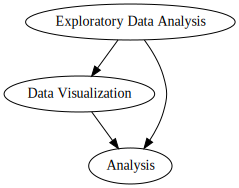

In [ ]:
from graphviz import Digraph


dot = Digraph()
dot.node("A", "Exploratory Data Analysis")
dot.node("B", "Data Visualization")
dot.node("C", "Analysis")
dot.edges(["AB", "BC", "AC"])
dot

# Exploratory Data Analysis (EDA)
Let’s begin with some simple descriptive statistics.

We’ll look at the **mean, standard deviation**, and **percentiles** — quick ways to understand the spread and shape of our data.

In [ ]:
data.describe()

,Method A,Method B,Method C
count,6.000000,6.000000,6.000000
mean,41.885000,42.981667,42.488333
std,30.525012,31.417903,28.845044
min,0.110000,0.190000,0.080000
25%,21.635000,22.405000,30.175000
50%,43.315000,43.655000,42.355000
75%,63.682500,66.990000,54.475000
max,79.690000,80.300000,85.510000


Next, let’s check how our variables relate to each other.

We can do a quick correlation analysis directly with `pandas`.

Give it a try and see which variables move together.

In [ ]:
data.corr()

,Method A,Method B,Method C
Method A,1.000000,0.998504,0.853327
Method B,0.998504,1.000000,0.869536
Method C,0.853327,0.869536,1.000000


# Data Visualization
Now for the fun part — **visualizing our data!**

`seaborn` makes it really easy to create professional-looking plots.

We’ll start with two of the most useful ones: **histograms** and **boxplots**.

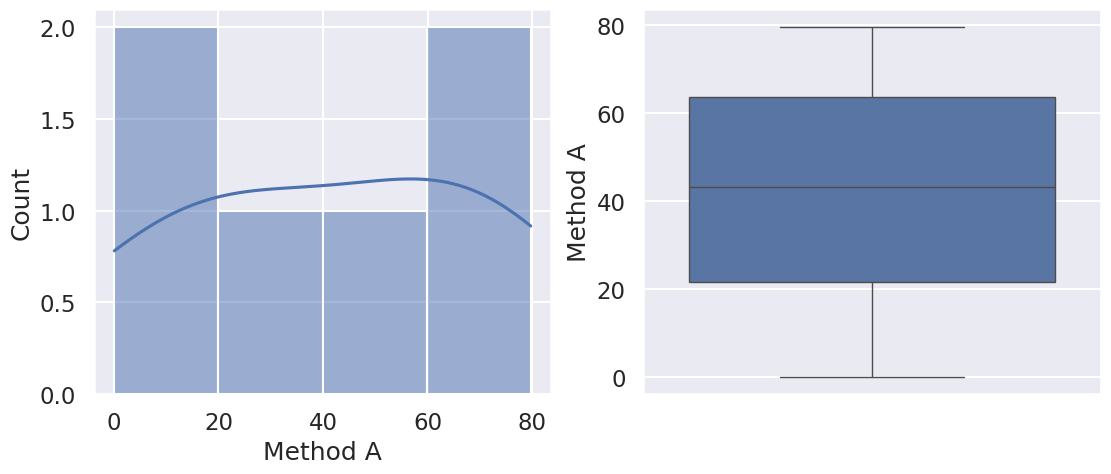

In [ ]:
gambar, rajah = plt.subplots(1, 2, figsize=(13,5))
sns.histplot(data=data, x="Method A", kde=True, ax=rajah[0])
sns.boxplot(data=data, y="Method A", ax=rajah[1])
plt.show()

Let’s continue with histograms for now — they’re great for showing how the data is distributed.

Using `matplotlib.pyplot.subplots`, we can display multiple histograms side-by-side in one figure.

By setting `sharey=True`, all histograms share the same y-axis scale, which makes comparison much easier.

Try changing that setting later and see how it affects the view!

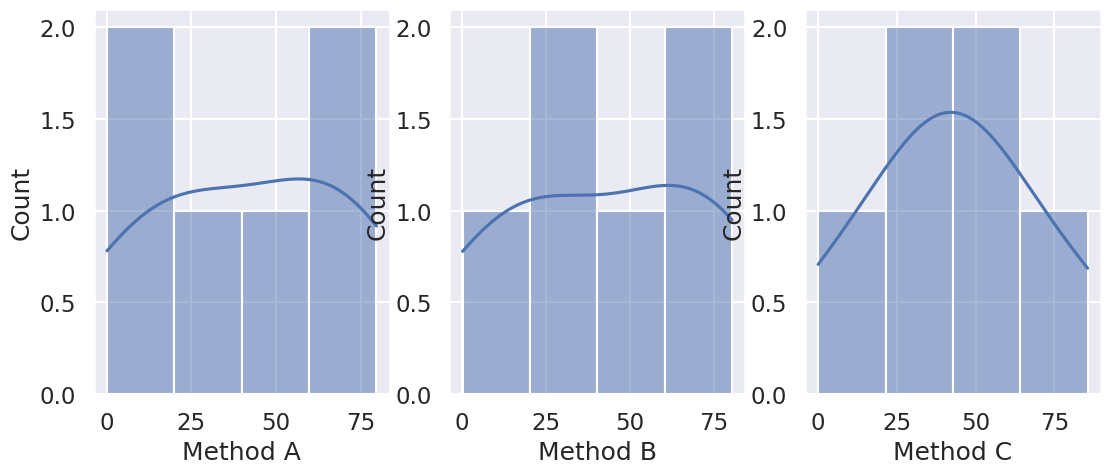

In [ ]:
gambar, rajah = plt.subplots(1, 3, figsize=(13,5), sharey=False)
sns.histplot(data=data, x="Method A", kde=True, ax=rajah[0])
sns.histplot(data=data, x="Method B", kde=True, ax=rajah[1])
sns.histplot(data=data, x="Method C", kde=True, ax=rajah[2])
plt.show()

If we adjust the parameters in `plt.subplots`, we can flip the layout from horizontal to vertical — a simple but powerful tweak.

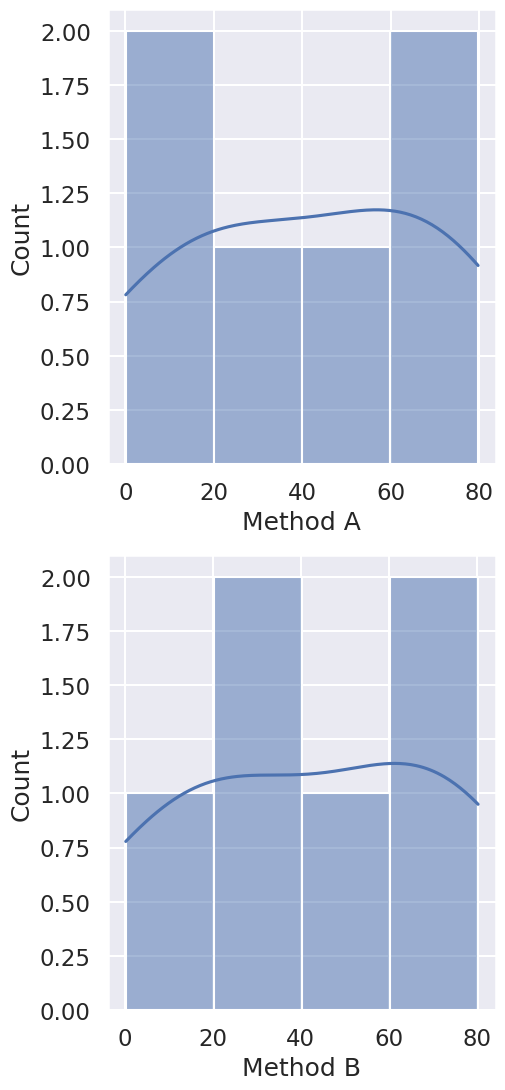

In [ ]:
gambar, rajah = plt.subplots(2, 1, figsize=(5,13))
sns.histplot(data=data, x="Method A", kde=True, ax=rajah[0])
sns.histplot(data=data, x="Method B", kde=True, ax=rajah[1])
plt.show()

And if we swap the `x` and `y` axes, we can even rotate the direction of the plots.

This is handy when you want to make your visualization fit nicely into a presentation slide or report.

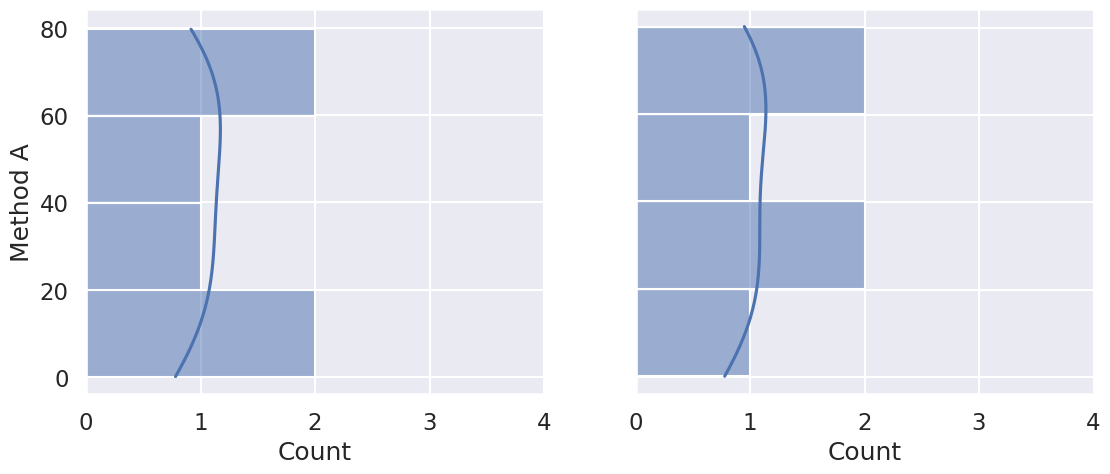

In [ ]:
gambar, rajah = plt.subplots(1, 2, figsize=(13,5), sharey=True, sharex=True)
sns.histplot(data=data, y="Method A", kde=True, ax=rajah[0])
sns.histplot(data=data, y="Method B", kde=True, ax=rajah[1])
rajah[1].set_xlim(0,4)
plt.show()

# Comparing Method A vs Method B — Bland–Altman Plot
Let’s move on to method comparison.

A **Bland–Altman plot** helps us assess the **agreement** between two measurement methods.

It shows the **difference** between the two measurements versus their **average**, letting us spot biases, outliers, or systematic differences.
In other words, it helps us decide whether two methods can be used interchangeably.

We can easily create this plot using the `pingouin` library.

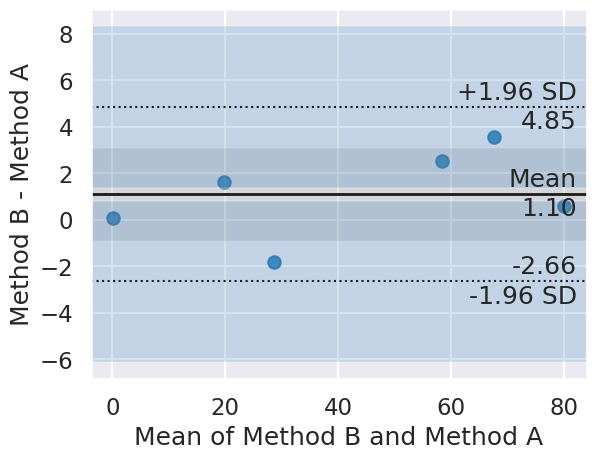

In [ ]:
pg.plot_blandaltman(x=data["Method B"], y=data["Method A"])
plt.show()

# Regression Analysis
Now, let’s explore **Ordinary Least Squares (OLS)** regression — a common method to find the best-fitting line through our data points.

It’s efficient, straightforward, and the results are easy to interpret.

Let’s run the regression using `pingouin`.

In [ ]:
pg.linear_regression(X=data["Method A"], y=data["Method B"])

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%]
0,Intercept,-0.064026,1.415581,-0.045229,0.966092,0.99701,0.996263,-3.994308,3.866256
1,Method A,1.027711,0.028139,36.523164,0.000003,0.99701,0.996263,0.949586,1.105837


We can also run a **correlation analysis** using the same library and compare the results with the regression output.

You’ll see how both tell a similar story — just from slightly different angles.

In [ ]:
pg.corr(x=data["Method A"], y=data["Method B"])

,n,r,CI95%,p-val,BF10,power
pearson,6,0.998504,"[0.99, 1.0]",0.000003,541.357,0.999996


Finally, let’s visualize the relationship using a `seaborn` **regression plot**.

Take a look at the slope and scatter — they help us quickly understand how strong the relationship is.

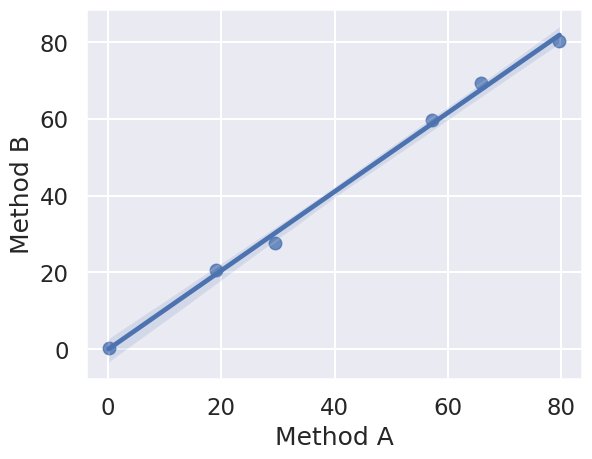

In [ ]:
sns.regplot(data=data, x="Method A", y="Method B")
plt.show()

# Comparing Method A vs Method C
Now let’s introduce **Method C**.

This one’s interesting because it shows a **significant difference** compared to Method A — we’ll use it to test how sensitive our analysis is.

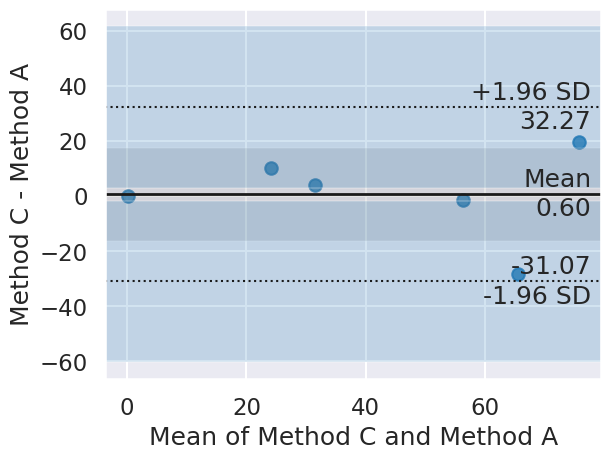

In [ ]:
pg.plot_blandaltman(x=data["Method C"], y=data["Method A"])
plt.show()

You might notice something: even though we know Method C is clearly different, our OLS regression didn’t detect it.

So what’s going on here?

Let’s think about why that might be.

In [ ]:
pg.linear_regression(X=data["Method A"], y=data["Method C"])

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%]
0,Intercept,8.713802,12.392769,0.703136,0.520740,0.728167,0.660209,-25.694041,43.121645
1,Method A,0.806363,0.246341,3.273364,0.030692,0.728167,0.660209,0.122411,1.490315


When we look at the regression plot, notice how the data points at the extremes show much **higher uncertainty**.

That gives us a clue — the variation isn’t uniform across the range, which can affect the regression results.

<Axes: xlabel='Method A', ylabel='Method C'>

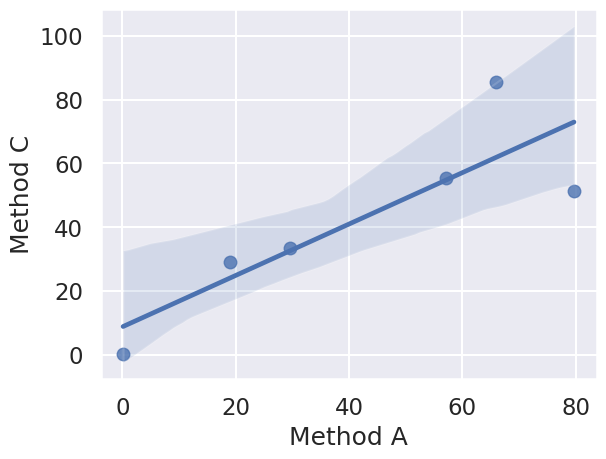

In [ ]:
sns.regplot(data=data, x="Method A", y="Method C")

# Assignment 1
## Raw Data
Do not click on the link to the raw data (below), you will end up downloading the raw data as a CSV file. Instead, copy and paste the link into your code.

https://docs.google.com/spreadsheets/d/1HTErkt3mwzlCwYIRyNCMGI1sgIJiSHOmv4b9DijYluc/export?format=csv&gid=362495675

## Instruction
Using Python in Google Colab, perform a method comparison analysis for each test method against the reference method. Your analysis should include the following components:
1. Exploratory Data Analysis (EDA)
* Inspect the dataset structure and summary statistics.
* Check for obvious data quality issues or anomalies.
2. Data Visualization
* Create appropriate plots to explore the relationship between the reference method and each test method.
* Include at least one plot that helps assess agreement or bias.
3. Analysis
* Perform suitable statistical analyses to compare each test method with the reference method.
* Use agreement and regression analysis where appropriate.

## Conclusion
For each test method, state whether there is evidence of:
* Fixed bias
* Proportional bias
* No significant bias
* Briefly justify your conclusion based on the results of your analysis.

## Submission
Share your Google Colab notebook and email the Colab link for submission. Ensure that your notebook contains clearly commented code, relevant plots, and a short written conclusion.

Send your answer to: ai3958905@gmail.com

# Assignment 2 (Bonus)
## Raw Data
Do not click on the link to the raw data (below), you will end up downloading the raw data as a CSV file. Instead, copy and paste the link into your code.

https://docs.google.com/spreadsheets/d/1BIshehQwB1TzIGZv6TDntmF5V3wzyGFXdgMFjzCqbcw/export?format=csv&gid=49867227

## Instruction
Follow the same instructions as Assignment 1 for data analysis, including EDA, data visualization, statistical analysis, and conclusion. In addition, include a short explanation addressing the following:
* When and why weighted least squares (WLS) regression should be used instead of ordinary least squares (OLS) regression.
* Your explanation should focus on the data characteristics and practical considerations, rather than mathematical derivations.

## Submission
Share your Google Colab notebook and email the Colab link for submission. Ensure that your notebook contains clearly commented code, relevant plots, and a short written conclusion.

Send your answer to: ai3958905@gmail.com